In [25]:
#julia version:1.11.6
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using ProgressMeter

In [34]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    sigma = 0.72
    gamma = 1.4
    # if Ro == -1
    #    A0,A1,A2 = Spatial_mode_BEK(-F,-G,-H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    # else 
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    # end
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval
end

eigsol (generic function with 1 method)

In [91]:
Tw = 1.2
Mr = 0.3
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
eta = CRD_BF.Physical_Interpretation(T,30/20000,20000)
z = range(0,30,20000)

0.0:0.0015000750037501875:30.0

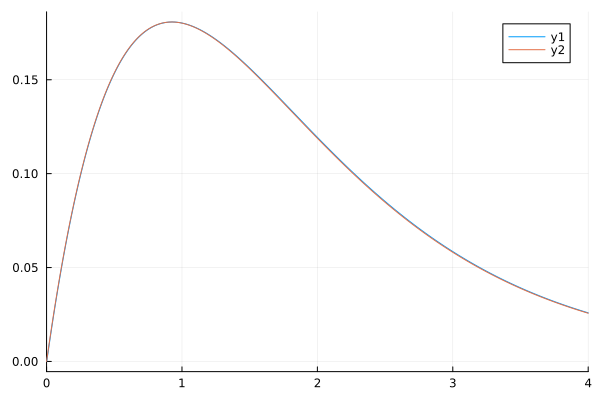

In [89]:
plot(eta,u0,xlims=[0,4])
plot!(z,u0)

In [94]:
writedlm("coord.dat",data)

In [82]:
N_cheb = 99
Ro = -1
Tw = 0.8
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = 0.04672
num = 1
omega = 0.0
data = [0 0 0 0 0]
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
# R = 440.88
# Ma = Mr/R
# eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.13,num)
# data = vcat(data,[R real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])])

([0.0; 0.0002824811191573318; … ; 9.013962809047516e-32; 9.013962809047516e-32;;], [0.0; -0.00034117928315047707; … ; -1.0; -1.0;;], [1.378838536211937e-26; -1.252096761240835e-7; … ; -0.8844741107344993; -0.8844741107344993;;], [0.8; 0.8000410682552204; … ; 0.9999999999963177; 0.9999999999963177;;], [1.25; 1.2499358341451927; … ; 1.0000000000036824; 1.0000000000036824;;], [0.0; 0.0005539326468201291; … ; 30.0; 30.0;;], [-0.5333333333333333; -0.5333607121701469; … ; -0.6666666666642118; -0.6666666666642118;;], [1.1111111111111112; 1.1111681503544726; … ; 1.3888888888837745; 1.3888888888837745;;], [-2970.151515151124 3611.390030573762 … -0.9093198110834142 0.45454545454545453; -902.4262223900014 451.0994992567002 … 0.45456220808173375 -0.2272238764335357; … ; 4.436834640202506e-8 -8.875904163768224e-8 … -8.80829037817145e-5 0.00017621017590984625; -0.0 0.0 … -0.0 0.0], [5.295001504873778e6 -8.41357312149442e6 … 5384.226905905448 -2691.424943501555; 2.444105391034474e6 -3.494561684232144

In [ ]:
plot(data[2:end,1],data[2:end,3])

In [ ]:
data = [0 0 0]
for N_cheb = 49 : 25 : 199
    Ro = -1
    Tw = 1
    Mr = 1.2
    R = 440
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    Ma = Mr/R
    be = 0.038
    num = 1
    omega = 0
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.1,num)
    data = vcat(data,[N_cheb real(eigval[1]) imag(eigval[1])])
end

In [13]:
cur(1.0,1.5,-1,0.0,500,0.2,0.05)

In [9]:
function cur(Tw,Mr,Ro,omega,R_ini,c_ini,be_ini)
    N_cheb = 199
    gamma = 1.4
    sigma = 0.72
    be_step = -0.0005
    num = 1
    Co = 2-Ro-Ro^2
    Ma = Mr/R_ini
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
    if imag(eigval[1]) < 0
        for be = be_ini :  be_step : -0.5
            sig_last = sign(imag(eigval[1]))
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
            sig_now = sign(imag(eigval[1]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last * sig_now < 0 && sig_last != 0 
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : - be_step : 0.5
            sig_last = sign(imag(eigval[1]))
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
            sig_now = sign(imag(eigval[1]))
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last * sig_now < 0 && sig_last != 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    end
    total = initial
    be = initial[3] - be_step
    dir = 0
    boundlen = 40
 # CACULATE

    while true
        index = findall(x->x==findmin([total[end,5],total[end,7]])[1],total[end,:])
        c = total[end,index[1] - 1]
        eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
        eigval_1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be - 0.0001,N_cheb,Ro,Co,D,D2,c,num)
        eigval_2 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be + 0.0001 * be_step,N_cheb,Ro,Co,D,D2,c,num)
        index1 = findmin(x-> (imag(x)) , eigval_1)[2]
        index2 = findmin(x-> (imag(x)) , eigval_2)[2]
        if 0.13<findmax(real,eigval)[1]<0.3
            num = 2
        else 
            num = 1
        end
        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <=2
            R_step = 0.25
        else
            R_step = 1
        end
        if (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) > 0) || (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) > 0) || dir == -1
            mode = 1
        elseif (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) < 0) || (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) < 0)
            mode = 2
        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 700

                Ma = Mr/R

                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]

                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0

                Ma = Mr/R
                
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end

        if mode == 1

            for R = total[end,2]: R_step : 700
                Ma = Mr/R

                if total[end,3] == be

                    break

                end 
                
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     

                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end
        c = total[end,4]
        Ma = Mr/total[end,2]
        eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2]+2,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
        sig = findmin(imag,eigval)[1]
        if size(total,1) > 10 &&total[end,3] != be 
            dir = -1 
            be_step = 0.0009
        else
            if sig > 0
                dir = -1
                be_step = 0.00075
            else
                dir = 1
                be_step = 0.00075
            end
        end
            be += dir * be_step
        filename = "ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Ma=$(Mr),Tw=$(Tw),Ro=$(Ro)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end
        if total[end,2] > 500 && size(total,1) > 30 && total[end,4] > 0.4
            break
        end
        # app = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat")
        # ori = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
        # if app[end,2] < ori[3,2]
        #     break
        # end
    end
end

cur (generic function with 1 method)

In [ ]:
all = [0 0 0 0]
R_ini = 600
c_ini = 0.05
be_ini = 0.03
Ro = -1
for omega in 0.0 : 0.002 : 0.01
    for Tw in 1.0 
        for Mr in 0.3
            N_cheb = 199
            gamma = 1.4
            sigma = 0.72
            be_step = -0.0002
            num = 1
            Co = 2-Ro-Ro^2
            Ma = Mr/R_ini
            F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
            initial = []
            tempvec_1 = [0 0 0 0 0 0 0]
            eigval = 0
            writedlm("output.dat",initial)
            writedlm("output_eig.dat",initial)
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
            if imag(eigval[1]) < 0
                for be = be_ini :  be_step : -0.5
                    sig_last = sign(imag(eigval[1]))
                    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
                    sig_now = sign(imag(eigval[1]))
                    # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
                    open("output_eig.dat", "a") do io
                        write(io,"be=$be,eig=$eigval\n")
                    end
                    if sig_last * sig_now < 0 && sig_last != 0 
                        initial = [omega Tw Mr be ]
                        break
                    end
                end
            elseif imag(eigval[1]) > 0
                for be = be_ini : - be_step : 0.5
                    sig_last = sign(imag(eigval[1]))
                    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
                    sig_now = sign(imag(eigval[1]))
                    open("output_eig.dat", "a") do io
                        write(io,"be=$be,eig=$eigval\n")
                    end
                    if sig_last * sig_now < 0 && sig_last != 0
                        initial = [omega Tw Mr be ]
                        break
                    end
                end
            end
            all = [all;initial]
            writedlm("test.dat",all)
        end
    end
end

In [ ]:
for omega in 0.008
    for Tw in 1.4
        for Mr in 0.3
            R_ini = 500
            c_ini = 0.05
            be_ini = 0.01
            Ro = -1
            cur(Tw,Mr,Ro,omega,R_ini,c_ini,be_ini)
        end
    end
end

In [ ]:
for omega = -0.025
    for Mr = 0.3 : 0.3 : 1.2
        for Tw = 0.8 : 0.1 : 1.2
            ori = readdlm("omega=$(omega)/ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
            all = [ori[1:260,:];ori[263:end,:]]
            writedlm("omega=$(omega)/ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat",all)
        end
    end
end

In [ ]:
using Statistics

In [ ]:
Ro = -1
for omega = 0
    for Mr = 0.3 : 0.3 : 1.2
        for Tw = 0.8 : 0.1 : 1.2
            
            str1 = "Zone T= \"omega=$(omega),Ma=$Mr,Tw=$Tw,INTER\" "
            str2 = "Variables=\"R\" \"beta\" "
            str3 = "Variables=\"omega\" \"R\" \"beta\" \"omega_r\" \"omega_i\" "
            str4 = "Zone T= \"omega=$(omega),Ma=$Mr,Tw=$Tw,ORIG\" "
            read_path = joinpath("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
            file_parh = joinpath("Interp_ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
            a0 = readdlm(read_path)
            a1 =  Matrix{Float32}(a0[3:end,:])
            k = 2
            p = sortperm(a1[:, k])
            a1 = a1[p, :]  
            x = a1[:,3]
            y = a1[:,2] 
            function sort_unique_xy(x::AbstractVector, y::AbstractVector)
                @assert length(x) == length(y) "x,y 长度不一致"
                p = sortperm(x)
                xs, ys = x[p], y[p]
                # 去掉重复 x（保留第一次出现）
                keep = [true; diff(xs) .> 0]
                return xs[keep], ys[keep]
            end
            xs, ys = sort_unique_xy(x, y)
            xq = range(xs[1], xs[end], length=500)
            yq_quad = pchip_interp_extrap(xs, ys, collect(xq); m=5, mode=:quad)
            function smooth_moving_avg(y; w)
                @assert isodd(w) "窗口 w 请设为奇数"
                r = (w-1)÷2
                ys = similar(y, Float64)
                for i in eachindex(y)
                    lo = max(firstindex(y), i-r)
                    hi = min(lastindex(y),  i+r)
                    ys[i] = Statistics.mean(@view y[lo:hi])
                end
                return ys
            end
            y_ma = smooth_moving_avg(yq_quad; w= eleven=13)  # 写法示例：w=11
            all = [y_ma xq]  
            open(file_parh,"w") do f
                println(f, str2)
                println(f, str1)
                writedlm(f, all)
            end
        end
    end
end